# Predictive Analysis — Classification

**IBM Data Science Capstone — SpaceX Falcon 9**

Repository: [https://github.com/MCerros/IBM-Data-Science-Capstone-SpaceX](https://github.com/MCerros/IBM-Data-Science-Capstone-SpaceX)

Direct notebook URL after upload:  
[https://github.com/MCerros/IBM-Data-Science-Capstone-SpaceX/blob/main/07_SpaceX_Machine_Learning.ipynb](https://github.com/MCerros/IBM-Data-Science-Capstone-SpaceX/blob/main/07_SpaceX_Machine_Learning.ipynb)

**Data integrity note:** This notebook uses the project CSV files stored in the same repository.
No rows, metrics, charts, or model scores are manually invented.

## Objective

Predict Falcon 9 first-stage landing success using:
- Logistic Regression
- Support Vector Machine (SVM)
- Decision Tree
- K-Nearest Neighbors (KNN)

`dataset_part_3.csv` is the feature matrix and `Class` from
`dataset_part_2.csv` is the target.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

X = pd.read_csv("dataset_part_3.csv")
y = pd.read_csv("dataset_part_2.csv")["Class"].to_numpy()

print("Feature matrix:", X.shape)
print("Target distribution:", dict(zip(*np.unique(y, return_counts=True))))

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-j4yrd8lj because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Feature matrix: (90, 83)
Target distribution: {np.int64(0): np.int64(30), np.int64(1): np.int64(60)}


In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=2,
)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

Training rows: 72
Test rows: 18


## Hyperparameter tuning

`GridSearchCV` with 10-fold cross-validation is used for every classifier.

In [3]:
model_specs = {
    "Logistic Regression": (
        LogisticRegression(max_iter=5000, random_state=2),
        {
            "C": np.logspace(-3, 3, 7),
            "solver": ["lbfgs"],
        },
    ),
    "SVM": (
        SVC(),
        {
            "kernel": ["linear", "rbf", "sigmoid"],
            "C": [0.1, 1, 10],
            "gamma": ["scale", "auto"],
        },
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=2),
        {
            "criterion": ["gini", "entropy", "log_loss"],
            "max_depth": [2, 4, 6, 8, 10],
            "min_samples_split": [2, 5, 10],
        },
    ),
    "KNN": (
        KNeighborsClassifier(),
        {
            "n_neighbors": list(range(1, 11)),
            "weights": ["uniform", "distance"],
            "p": [1, 2],
        },
    ),
}

In [4]:
fitted = {}
rows = []

for name, (model, params) in model_specs.items():
    search = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=10,
        scoring="accuracy",
        n_jobs=-1,
    )
    search.fit(X_train, y_train)
    pred = search.best_estimator_.predict(X_test)

    fitted[name] = search
    rows.append({
        "Model": name,
        "CV Accuracy": search.best_score_,
        "Test Accuracy": accuracy_score(y_test, pred),
        "Best Parameters": search.best_params_,
    })

results = pd.DataFrame(rows).sort_values(
    ["Test Accuracy", "CV Accuracy"],
    ascending=False,
)
results

Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 124, in start_daemon
TimeoutError: Timed out waiting for artifact tool daemon socket. Set ARTIFACT_TOOL_RPC_DAEMON_STARTUP_TIMEOUT_S=<seconds> to increase the limit.
Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_

Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 124, in start_daemon
TimeoutError: Timed out waiting for artifact tool daemon socket. Set ARTIFACT_TOOL_RPC_DAEMON_STARTUP_TIMEOUT_S=<seconds> to increase the limit.


Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 124, in start_daemon
TimeoutError: Timed out waiting for artifact tool daemon socket. Set ARTIFACT_TOOL_RPC_DAEMON_STARTUP_TIMEOUT_S=<seconds> to increase the limit.


Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 124, in start_daemon
TimeoutError: Timed out waiting for artifact tool daemon socket. Set ARTIFACT_TOOL_RPC_DAEMON_STARTUP_TIMEOUT_S=<seconds> to increase the limit.


,Model,CV Accuracy,Test Accuracy,Best Parameters
1,SVM,0.848214,0.833333,"{'C': 1, 'gamma': 'scale', 'kernel': 'sigmoid'}"
3,KNN,0.848214,0.833333,"{'n_neighbors': 10, 'p': 1, 'weights': 'uniform'}"
0,Logistic Regression,0.846429,0.833333,"{'C': 0.01, 'solver': 'lbfgs'}"
2,Decision Tree,0.803571,0.833333,"{'criterion': 'gini', 'max_depth': 2, 'min_sam..."


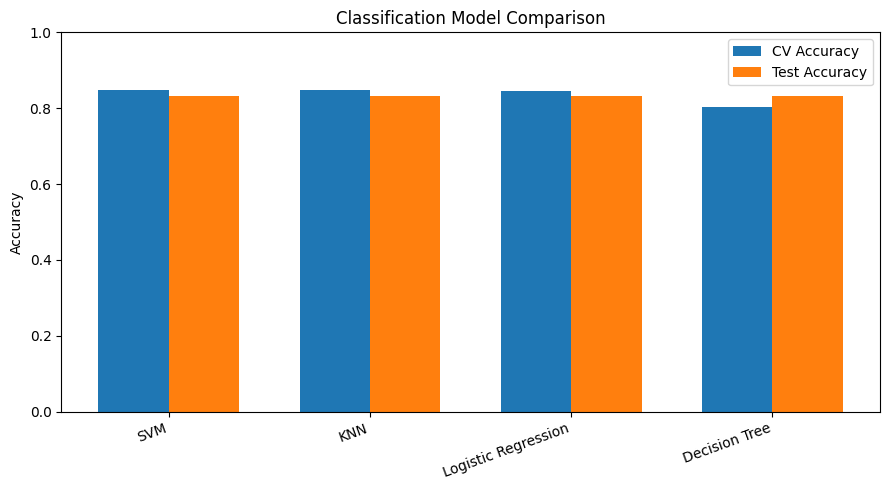

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results))
width = 0.35

ax.bar(x - width/2, results["CV Accuracy"], width, label="CV Accuracy")
ax.bar(x + width/2, results["Test Accuracy"], width, label="Test Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(results["Model"], rotation=20, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_title("Classification Model Comparison")
ax.legend()
plt.tight_layout()
plt.show()

Selected model for confusion matrix: SVM
Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'sigmoid'}
Test accuracy: 0.8333333333333334
Confusion matrix:
[[ 3  3]
 [ 0 12]]


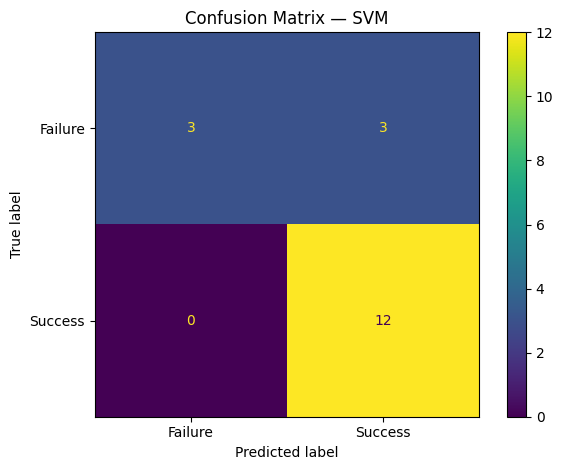

In [6]:
best_name = results.iloc[0]["Model"]
best_search = fitted[best_name]
best_pred = best_search.best_estimator_.predict(X_test)

print("Selected model for confusion matrix:", best_name)
print("Best parameters:", best_search.best_params_)
print("Test accuracy:", accuracy_score(y_test, best_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, best_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    display_labels=["Failure", "Success"],
)
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()

In [7]:
top_test = results["Test Accuracy"].max()
tied_test = results[results["Test Accuracy"] == top_test]["Model"].tolist()

print(f"Highest hold-out test accuracy: {top_test:.4f}")
print("Models tied at the highest test accuracy:", tied_test)

if len(tied_test) > 1:
    print(
        "Several classifiers tie on the hold-out test set; "
        "cross-validation performance and model simplicity should also be considered."
    )
else:
    print(f"{tied_test[0]} has the highest hold-out test accuracy.")

Highest hold-out test accuracy: 0.8333
Models tied at the highest test accuracy: ['SVM', 'KNN', 'Logistic Regression', 'Decision Tree']
Several classifiers tie on the hold-out test set; cross-validation performance and model simplicity should also be considered.
